In [2]:
!pip install ripser

  Using cached ripser-0.6.14-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 33.7 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 32.2 MB/s  0:00:00 43.3 MB/s eta 0:00:01
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18187 sha256=c0fca9fb6dfe05796b4e82dfaecbc33987f27e0f90a7e9d872a3b202c7c89da8
  Stored in directory: /home/jp/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [ripser]━━━━━━━━━━━ 6/9 [deprecated]


Initializing Pre-2008 Interbank Topology...
Running TDA Sliding Window over Time Series...
TDA computation complete. Plotting the Hysteresis Loop...


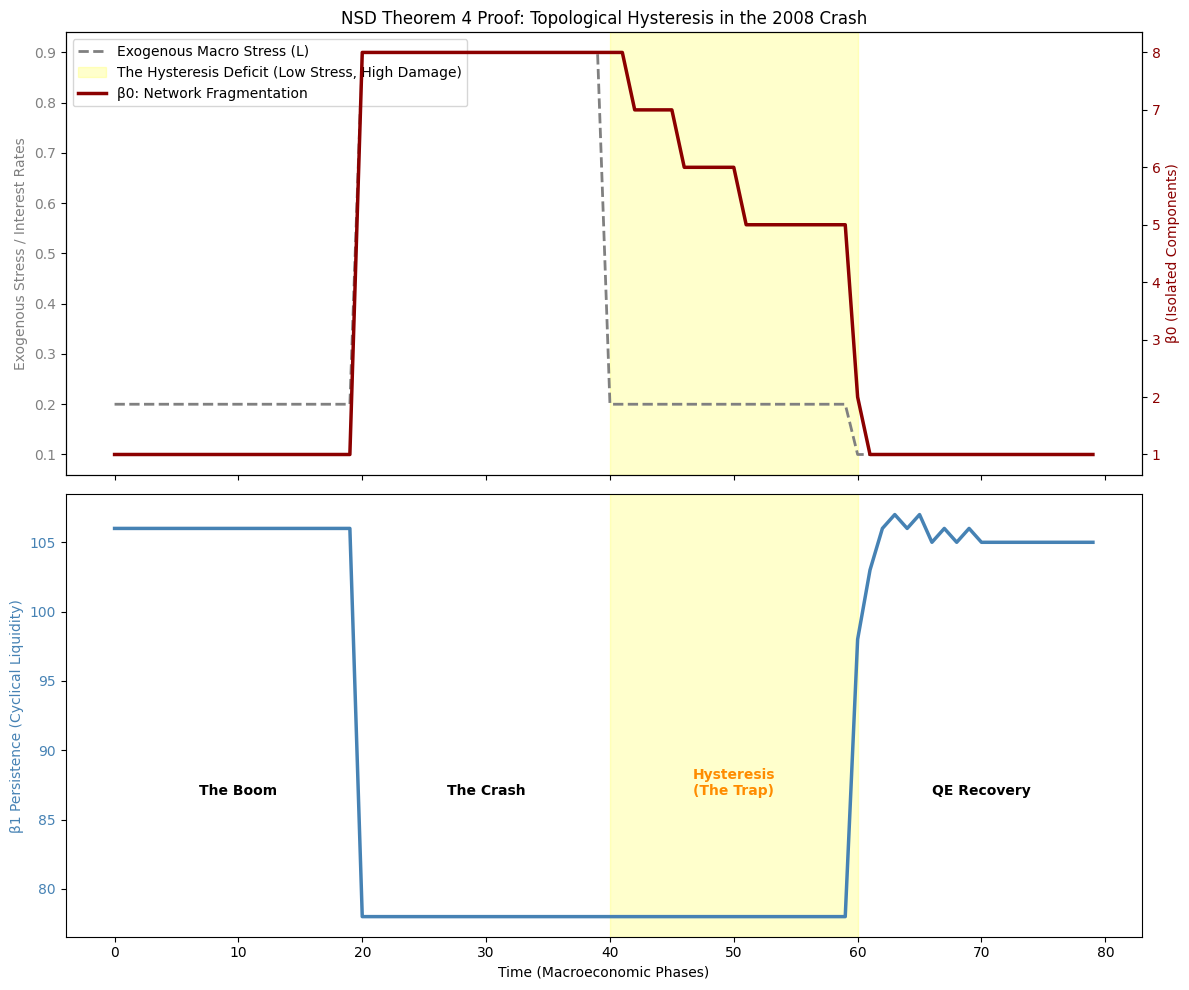

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from ripser import ripser
import copy
import warnings
warnings.filterwarnings("ignore")

def prove_theorem_4_tda_hysteresis(time_steps=80, N=100):
    print("Initializing Pre-2008 Interbank Topology...")
    # 1. Initialize Healthy Scale-Free Network (Pre-2008)
    G_base = nx.barabasi_albert_graph(N, 3)
    edges_base = list(G_base.edges())
    hubs = sorted(dict(G_base.degree()), key=dict(G_base.degree()).get, reverse=True)[:5]
    
    G = copy.deepcopy(G_base)
    
    # Tracking metrics
    betti_0_list = []
    betti_1_list = []
    macro_stress_list = []
    
    print("Running TDA Sliding Window over Time Series...")
    for t in range(time_steps):
        
        # --- PHASE 1: The Boom (t=0 to 19) ---
        if t < 20:
            macro_stress = 0.2  # Normal economic load
            
        # --- PHASE 2: The Crash (t=20 to 39) ---
        elif t < 40:
            macro_stress = 0.9  # Subprime shock hits
            # Hubs undergo saddle-node burnout; edges are violently severed
            edges_to_remove = []
            for hub in hubs:
                edges_to_remove.extend(list(G.edges(hub)))
            G.remove_edges_from(edges_to_remove)
            
        # --- PHASE 3: The Hysteresis Deficit (t=40 to 59) ---
        elif t < 60:
            # The Paradox: Central banks slash interest rates to 0 (Stress drops back to normal)
            macro_stress = 0.2  
            # BUT the network topology does NOT naturally heal. 
            # Trust is gone. Only a tiny trickle of random edges reform.
            if np.random.rand() > 0.5:
                random_edge = edges_base[np.random.randint(0, len(edges_base))]
                G.add_edge(*random_edge)
                
        # --- PHASE 4: The Thermodynamic Rescue / QE (t=60 to 80) ---
        else:
            macro_stress = 0.1  # Extreme baseline easing
            # Massive thermodynamic work (Quantitative Easing) forcefully rebuilds capacity
            # Banks are recapitalized and forced to lend, restoring the topology
            missing_edges = [e for e in edges_base if not G.has_edge(*e)]
            np.random.shuffle(missing_edges)
            G.add_edges_from(missing_edges[:int(len(missing_edges)*0.3)]) # Rapid rebuild

        # --- TOPOLOGICAL DATA ANALYSIS (TDA) ---
        # Calculate distance matrix (shortest path). Unconnected nodes have infinite distance.
        dist_matrix = nx.floyd_warshall_numpy(G)
        # Replace infinities with a large number for Ripser to process fragmentation
        np.nan_to_num(dist_matrix, copy=False, nan=999, posinf=999)
        
        # Compute Persistent Homology
        diagrams = ripser(dist_matrix, distance_matrix=True, maxdim=1)['dgms']
        H0 = diagrams[0]
        H1 = diagrams[1]
        
        # β0: Number of fragmented, isolated components (infinite death)
        b0 = len([d for d in H0 if d[1] == np.inf or d[1] > 900])
        
        # β1: Systemic Liquidity Loops (Sum of persistence of cycles)
        if len(H1) > 0:
            b1_persistence = sum([d[1] - d[0] for d in H1 if d[1] != np.inf])
        else:
            b1_persistence = 0
            
        betti_0_list.append(b0)
        betti_1_list.append(b1_persistence)
        macro_stress_list.append(macro_stress)

    print("TDA computation complete. Plotting the Hysteresis Loop...")
    
    # --- VISUALIZATION ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Top Plot: Macro Stress vs Fragmentation (β0)
    ax1.plot(macro_stress_list, color='gray', linestyle='--', linewidth=2, label='Exogenous Macro Stress (L)')
    ax1.set_ylabel('Exogenous Stress / Interest Rates', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    ax1.axvspan(40, 60, color='yellow', alpha=0.2, label='The Hysteresis Deficit (Low Stress, High Damage)')
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(betti_0_list, color='darkred', linewidth=2.5, label='β0: Network Fragmentation')
    ax1_twin.set_ylabel('β0 (Isolated Components)', color='darkred')
    ax1_twin.tick_params(axis='y', labelcolor='darkred')
    ax1.set_title('NSD Theorem 4 Proof: Topological Hysteresis in the 2008 Crash')
    
    # Combine legends for top plot
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # Bottom Plot: The Evaporation of Liquidity Loops (β1)
    ax2.plot(betti_1_list, color='steelblue', linewidth=2.5, label='β1: Liquidity Loops (Trust Cycles)')
    ax2.set_ylabel('β1 Persistence (Cyclical Liquidity)', color='steelblue')
    ax2.set_xlabel('Time (Macroeconomic Phases)')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    ax2.axvspan(40, 60, color='yellow', alpha=0.2)
    
    # Labels for phases
    ax2.text(10, ax2.get_ylim()[1]*0.8, 'The Boom', ha='center', fontweight='bold')
    ax2.text(30, ax2.get_ylim()[1]*0.8, 'The Crash', ha='center', fontweight='bold')
    ax2.text(50, ax2.get_ylim()[1]*0.8, 'Hysteresis\n(The Trap)', ha='center', fontweight='bold', color='darkorange')
    ax2.text(70, ax2.get_ylim()[1]*0.8, 'QE Recovery', ha='center', fontweight='bold')

    fig.tight_layout()
    plt.show()

prove_theorem_4_tda_hysteresis()